In [1]:
!pip -q install pandas numpy matplotlib seaborn scipy openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
regions = [
    "PIVC",
    "TPJ",
    "Hippocampus",
    "Parietal",
    "Cerebellum",
    "Insula"
]

tasks = [
    "virtual_navigation",
    "mental_rotation",
    "self_motion",
    "landmark_memory"
]

rows = []

for task in tasks:
    for region in regions:
        score = {
            "PIVC": 0.72,
            "TPJ": 0.64,
            "Hippocampus": 0.69,
            "Parietal": 0.58,
            "Cerebellum": 0.47,
            "Insula": 0.52
        }[region] + np.random.normal(0, 0.06)

        rows.append([task, region, score])

df = pd.DataFrame(rows, columns=["task", "region", "connectivity_score"])
df.head()

,task,region,connectivity_score
0,virtual_navigation,PIVC,0.749803
1,virtual_navigation,TPJ,0.631704
2,virtual_navigation,Hippocampus,0.728861
3,virtual_navigation,Parietal,0.671382
4,virtual_navigation,Cerebellum,0.455951


In [4]:
summary = (
    df.groupby("region")["connectivity_score"]
    .mean()
    .reset_index()
    .sort_values("connectivity_score", ascending=False)
)

summary

,region,connectivity_score
3,PIVC,0.741148
1,Hippocampus,0.688784
5,TPJ,0.599554
4,Parietal,0.599163
2,Insula,0.492844
0,Cerebellum,0.445357


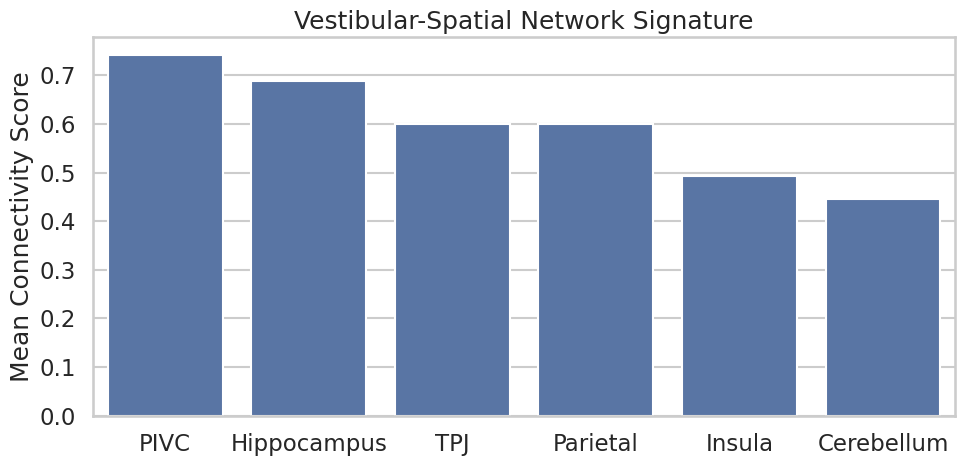

In [5]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=summary,
    x="region",
    y="connectivity_score"
)

plt.xlabel("")
plt.ylabel("Mean Connectivity Score")
plt.title("Vestibular-Spatial Network Signature")
plt.tight_layout()
plt.savefig("figures/02_network_signature_barplot.png", dpi=300)
plt.show()

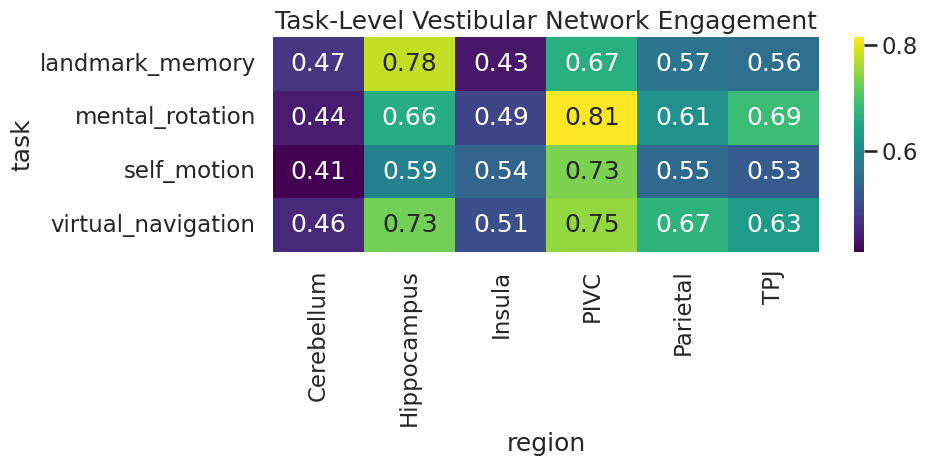

In [6]:
pivot = df.pivot(index="task", columns="region", values="connectivity_score")

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

plt.title("Task-Level Vestibular Network Engagement")
plt.tight_layout()
plt.savefig("figures/02_task_heatmap.png", dpi=300)
plt.show()

In [7]:
summary.to_csv("outputs/02_network_signature.csv", index=False)
df.to_csv("outputs/02_task_region_scores.csv", index=False)

summary

,region,connectivity_score
3,PIVC,0.741148
1,Hippocampus,0.688784
5,TPJ,0.599554
4,Parietal,0.599163
2,Insula,0.492844
0,Cerebellum,0.445357
